# Gen Z Mental Wellness & Digital Lifestyle Analysis

[Link](https://www.kaggle.com/datasets/hammadansari7/gen-z-mental-wellness-and-digital-lifestyle-patterns)

# Configuração do Ambiente

In [2]:
import os
import numpy as np
import pandas as pd
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier


import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Carga do Dataset

O Gen Z Mental Wellness & Digital Lifestyle Patterns Dataset é um conjunto de dados sintético que modela a relação entre hábitos digitais, estilo de vida e indicadores de bem-estar psicológico em jovens de 18 a 26 anos. Ele simula correlações realistas entre uso de telas, sono, exercícios e aspectos emocionais, sendo voltado para análise e modelagem de dados. Os indicadores psicológicos são apenas simulados e não possuem validade clínica.

### Colunas do dataset:

- Age: Idade (18–26)
- Gender: Gênero (Male, Female, Non-binary)
- Country: País de residência
- Student_Working_Status: Situação (Student, Working, Both)
- Daily_Social_Media_Hours: Média diária de uso de redes sociais
- Screen_Time_Hours: Tempo total diário de tela
- Night_Scrolling_Frequency: Frequência de uso do celular à noite
- Online_Gaming_Hours: Horas diárias de jogos online
- Content_Type_Preference: Tipo principal de conteúdo consumido
- Exercise_Frequency_per_Week: Frequência de exercícios por semana
- Daily_Sleep_Hours: Horas de sono por dia
- Caffeine_Intake_Cups: Consumo diário de cafeína (xícaras)
- Study_Work_Hours_per_Day: Horas diárias de estudo/trabalho
- Overthinking_Score: Nível de overthinking (1–10)
- Anxiety_Score: Nível de ansiedade (1–10)
- Mood_Stability_Score: Estabilidade de humor (1–10)
- Social_Comparison_Index: Tendência à comparação social (1–10)
- Sleep_Quality_Score: Qualidade do sono (1–10)
- Motivation_Level: Nível de motivação (1–10)
- Emotional_Fatigue_Score: Fadiga emocional (1–10)
- Wellbeing_Index: Índice composto de bem-estar (variável alvo contínua)
- Burnout_Risk: Risco de burnout (Low, Medium, High)

O objetivo é prever se um indivíduo da geração z tem risco de burnout em relação a suas características comportamentais e rotineiras.

In [3]:
df_original = pd.read_csv("https://raw.githubusercontent.com/piresthiago10/mvp_quarta_sprint_backend/refs/heads/main/app/machine_learning/data/genz_mental_wellness_synthetic_dataset.csv", sep = ',')

In [4]:
df_original.shape

(10000, 22)

In [5]:
df_original.head()

,Age,Gender,Country,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,Exercise_Frequency_per_Week,Daily_Sleep_Hours,Caffeine_Intake_Cups,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk
0,24,Male,Canada,Working,4.81,6.93,2.61,2.07,News,5.41,6.84,1.52,11.42,4.95,4.13,5.74,4.67,6.27,6.13,6.45,4.28,Medium
1,21,Male,USA,Student,4.16,7.94,1.85,3.58,Gaming,3.41,7.88,2.23,6.98,5.91,3.63,5.75,5.38,7.37,6.27,3.74,5.23,Medium
2,25,Male,Pakistan,Student,3.07,7.45,2.96,2.85,Entertainment,3.40,6.39,0.53,7.79,4.06,5.67,6.03,2.41,6.48,4.82,6.69,3.72,High
3,22,Female,Pakistan,Student,4.41,7.34,4.51,3.37,Educational,2.19,7.92,0.58,6.61,6.10,4.78,4.85,5.86,7.27,5.17,5.96,3.97,High
4,24,Male,Pakistan,Student,2.97,5.76,2.36,1.77,Educational,4.93,5.97,1.64,4.81,5.22,4.23,5.05,5.54,6.34,5.72,2.22,4.63,Medium


In [6]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          10000 non-null  int64  
 1   Gender                       10000 non-null  str    
 2   Country                      10000 non-null  str    
 3   Student_Working_Status       10000 non-null  str    
 4   Daily_Social_Media_Hours     10000 non-null  float64
 5   Screen_Time_Hours            10000 non-null  float64
 6   Night_Scrolling_Frequency    10000 non-null  float64
 7   Online_Gaming_Hours          10000 non-null  float64
 8   Content_Type_Preference      10000 non-null  str    
 9   Exercise_Frequency_per_Week  10000 non-null  float64
 10  Daily_Sleep_Hours            10000 non-null  float64
 11  Caffeine_Intake_Cups         10000 non-null  float64
 12  Study_Work_Hours_per_Day     10000 non-null  float64
 13  Overthinking_Score          

In [7]:
df_original = df_original.drop(columns=['Country'])

In [8]:
df_original.describe()

,Age,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Exercise_Frequency_per_Week,Daily_Sleep_Hours,Caffeine_Intake_Cups,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,21.992900,4.005883,7.016991,2.986009,1.607241,2.994855,6.512031,1.505871,6.030983,5.001868,4.747556,5.161021,4.403556,6.514447,5.086132,5.582222,3.870213
std,2.589309,1.480509,1.792529,1.197035,1.300045,1.478248,1.194194,0.934069,1.975337,1.143179,1.305593,1.257055,1.336479,1.427806,1.308351,1.416558,1.238940
min,18.000000,0.500000,2.000000,0.000000,0.000000,0.000000,3.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.020000,1.000000,1.000000,1.000000
25%,20.000000,3.010000,5.810000,2.187500,0.470000,1.960000,5.710000,0.800000,4.700000,4.240000,3.840000,4.310000,3.470000,5.550000,4.200000,4.620000,3.020000
50%,22.000000,3.990000,7.000000,2.980000,1.460000,3.010000,6.520000,1.480000,6.030000,5.000000,4.740000,5.170000,4.400000,6.530000,5.080000,5.580000,3.870000
75%,24.000000,4.982500,8.210000,3.790000,2.500000,4.000000,7.320000,2.150000,7.340000,5.760000,5.630000,6.000000,5.320000,7.490000,5.950000,6.540000,4.700000
max,26.000000,10.000000,14.000000,7.000000,6.000000,7.000000,10.000000,6.000000,13.050000,9.510000,9.690000,10.000000,9.420000,10.000000,10.000000,10.000000,8.860000


In [9]:
print(df_original.isna().sum())

Age                            0
Gender                         0
Student_Working_Status         0
Daily_Social_Media_Hours       0
Screen_Time_Hours              0
Night_Scrolling_Frequency      0
Online_Gaming_Hours            0
Content_Type_Preference        0
Exercise_Frequency_per_Week    0
Daily_Sleep_Hours              0
Caffeine_Intake_Cups           0
Study_Work_Hours_per_Day       0
Overthinking_Score             0
Anxiety_Score                  0
Mood_Stability_Score           0
Social_Comparison_Index        0
Sleep_Quality_Score            0
Motivation_Level               0
Emotional_Fatigue_Score        0
Wellbeing_Index                0
Burnout_Risk                   0
dtype: int64


In [10]:
df_original.nunique()

Age                               9
Gender                            3
Student_Working_Status            3
Daily_Social_Media_Hours        755
Screen_Time_Hours               933
Night_Scrolling_Frequency       629
Online_Gaming_Hours             551
Content_Type_Preference           5
Exercise_Frequency_per_Week     682
Daily_Sleep_Hours               650
Caffeine_Intake_Cups            430
Study_Work_Hours_per_Day       1002
Overthinking_Score              657
Anxiety_Score                   708
Mood_Stability_Score            704
Social_Comparison_Index         698
Sleep_Quality_Score             737
Motivation_Level                716
Emotional_Fatigue_Score         776
Wellbeing_Index                 641
Burnout_Risk                      3
dtype: int64

## Analisando variáveis categoricas

In [11]:
df_original.groupby(['Gender']).size()

Gender
Female        4481
Male          4547
Non-binary     972
dtype: int64

In [12]:
df_original.groupby(['Student_Working_Status']).size()

Student_Working_Status
Both        973
Student    5971
Working    3056
dtype: int64

In [13]:
df_original.groupby(['Content_Type_Preference']).size()

Content_Type_Preference
Educational      1961
Entertainment    1994
Gaming           2051
Lifestyle        1964
News             2030
dtype: int64

In [14]:
df_original.groupby(['Burnout_Risk']).size()

Burnout_Risk
High      5388
Low         64
Medium    4548
dtype: int64

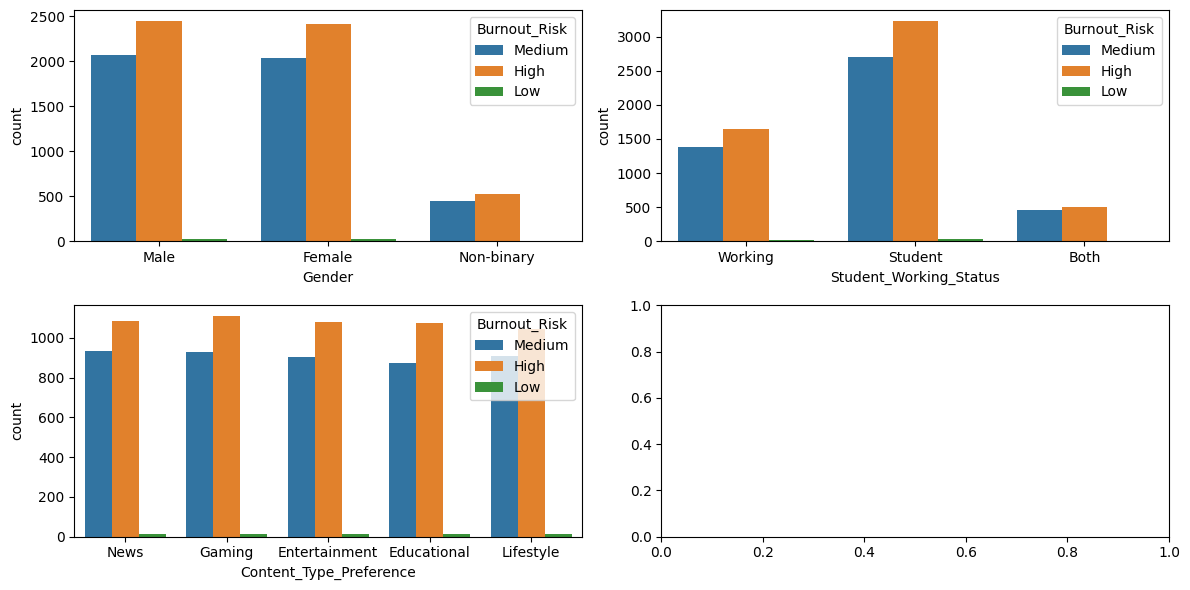

In [15]:
plt.rcParams["figure.figsize"] = [12.00, 6.00]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(2, 2)
sns.countplot(data=df_original, x="Gender", hue="Burnout_Risk", ax=axes[0, 0])
sns.countplot(data=df_original, x="Student_Working_Status", hue="Burnout_Risk", ax=axes[0, 1])
sns.countplot(data=df_original, x="Content_Type_Preference", hue="Burnout_Risk", ax=axes[1, 0])
plt.tight_layout()
plt.show()

## Analisando as Variaveis Numéricas

In [16]:
variaveis_numericas = []
for i in df_original.columns[0:22].tolist():
        if df_original.dtypes[i] in ['int64', 'float64']:
            print(i, ':' , df_original.dtypes[i])
            variaveis_numericas.append(i)

Age : int64
Daily_Social_Media_Hours : float64
Screen_Time_Hours : float64
Night_Scrolling_Frequency : float64
Online_Gaming_Hours : float64
Exercise_Frequency_per_Week : float64
Daily_Sleep_Hours : float64
Caffeine_Intake_Cups : float64
Study_Work_Hours_per_Day : float64
Overthinking_Score : float64
Anxiety_Score : float64
Mood_Stability_Score : float64
Social_Comparison_Index : float64
Sleep_Quality_Score : float64
Motivation_Level : float64
Emotional_Fatigue_Score : float64
Wellbeing_Index : float64


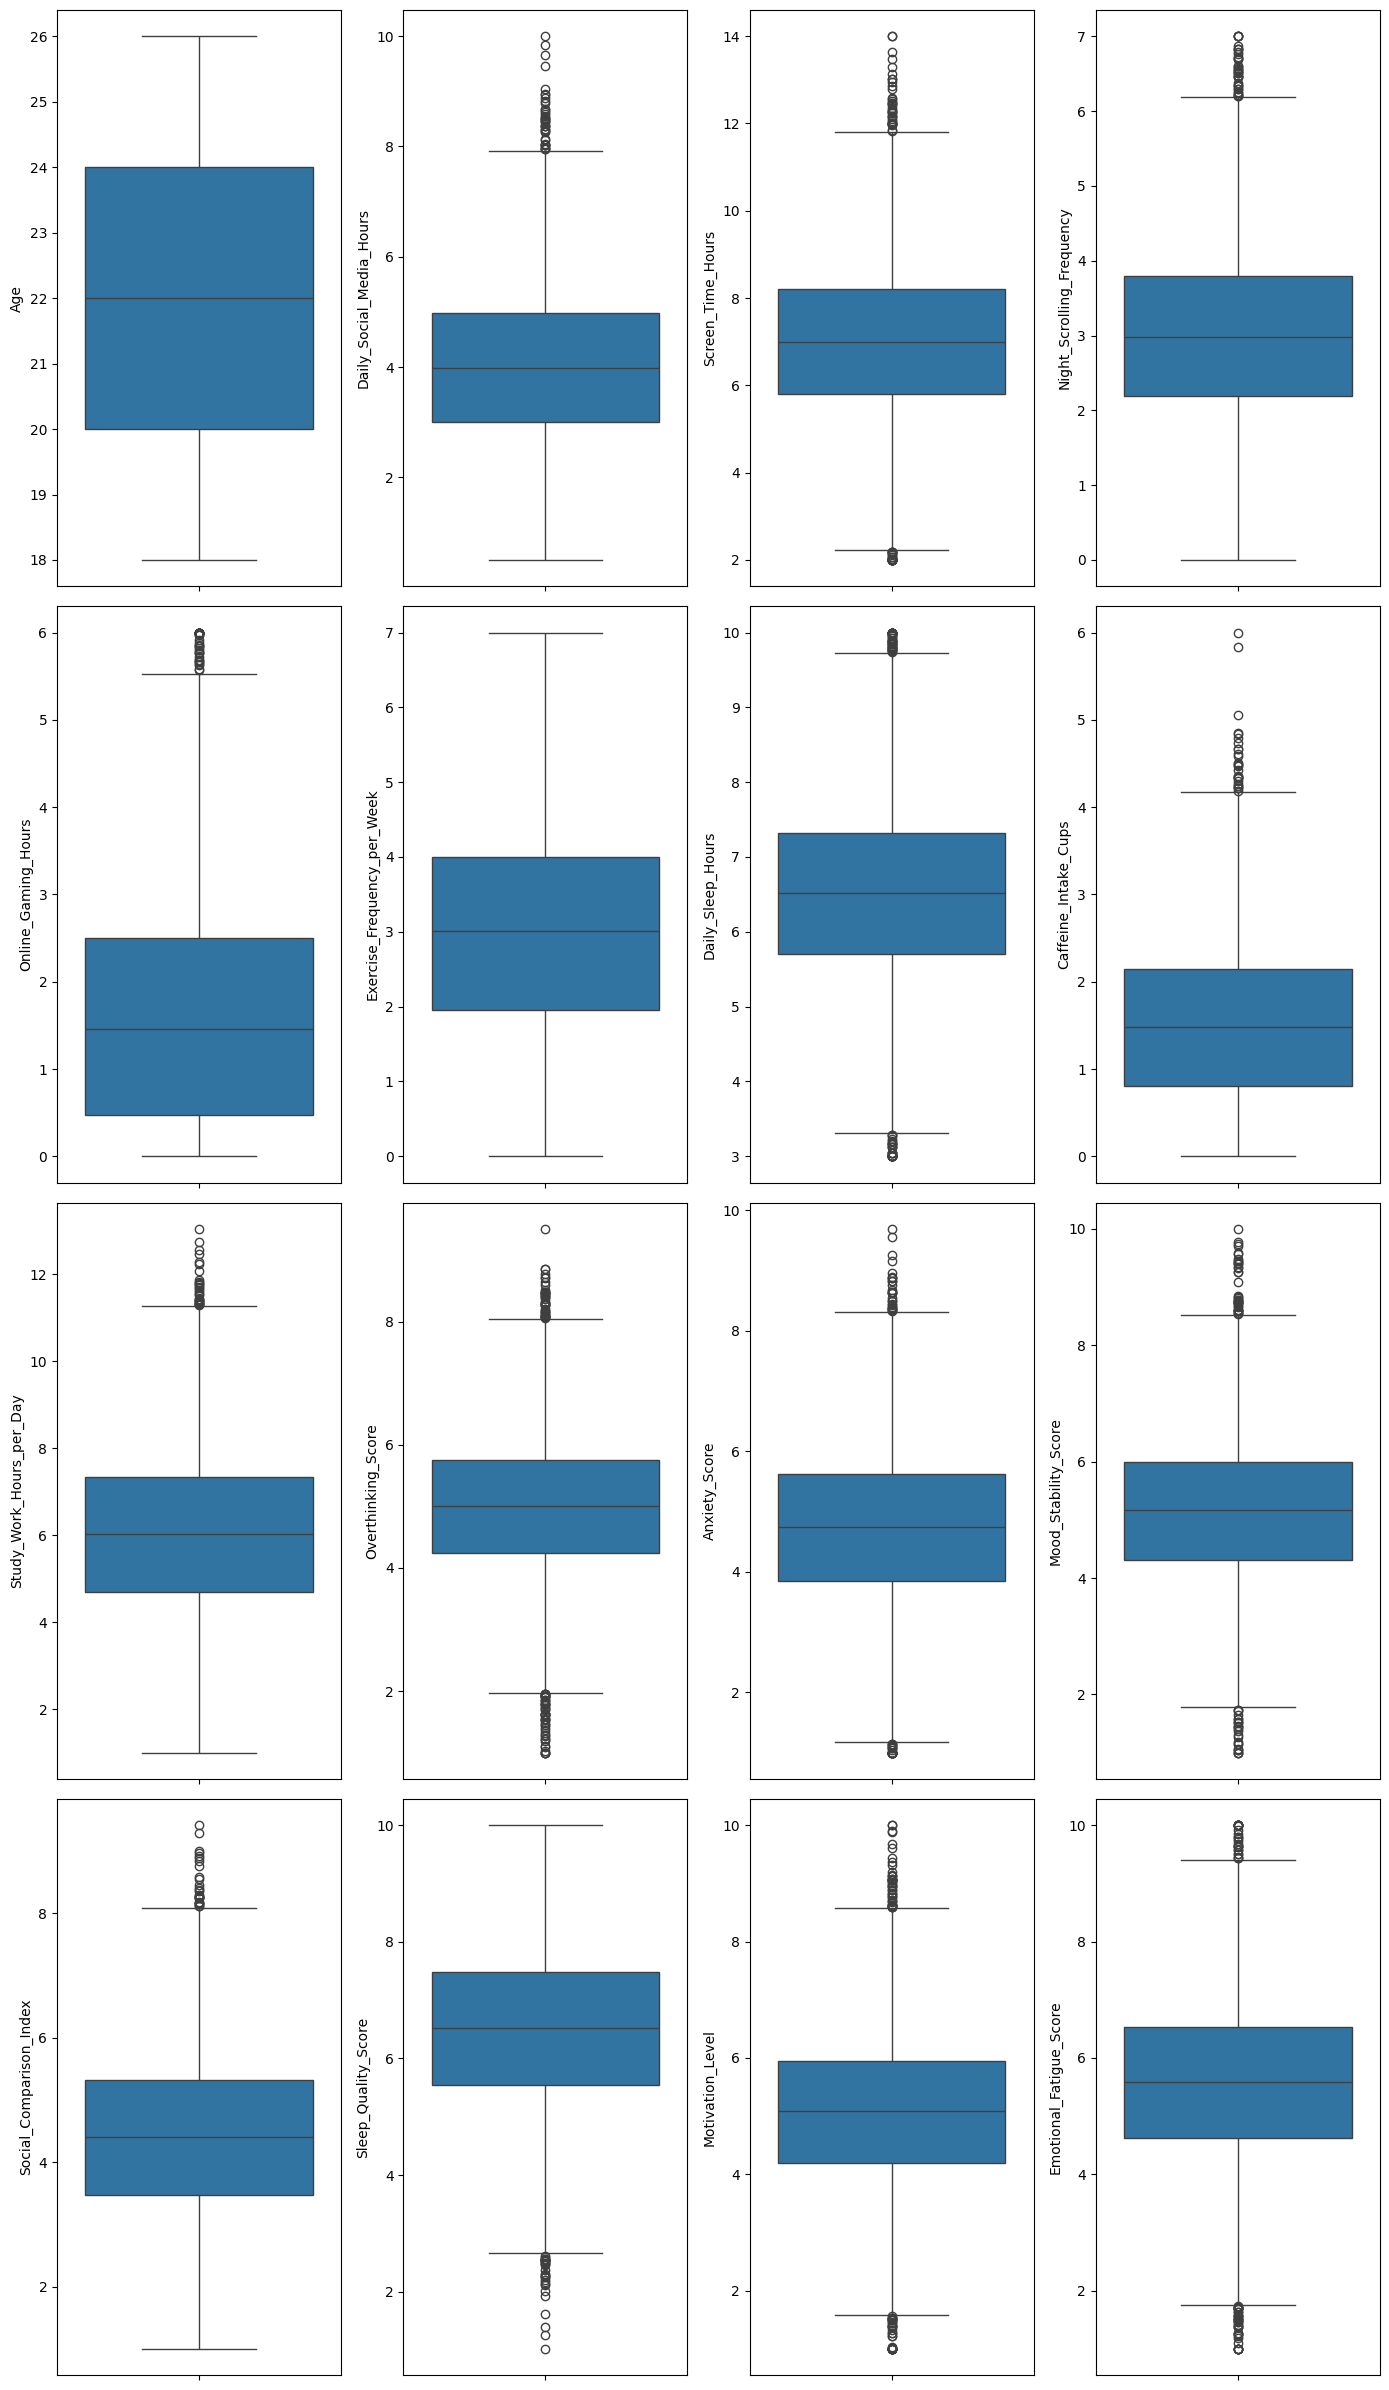

In [17]:
plt.rcParams["figure.figsize"] = [14.00, 24.00]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(4, 4) #4 linhas e 4 colunas

linha = 0
coluna = 0
try:
    for i in variaveis_numericas:
        sns.boxplot(data = df_original, y=i, ax=axes[linha][coluna])
        coluna += 1
        if coluna == 4:
            linha += 1
            coluna = 0
except IndexError:
    pass

plt.show()

# Limpeza e tratamento dos dados

In [18]:
df_copy = df_original.copy()

In [19]:
df_copy["Daily_Social_Media_Hours"] = df_copy["Daily_Social_Media_Hours"].round()
df_copy["Daily_Social_Media_Hours"] = df_copy["Daily_Social_Media_Hours"].clip(1.0, 7.0)
df_copy.groupby(['Daily_Social_Media_Hours']).size()

Daily_Social_Media_Hours
1.0     487
2.0    1072
3.0    2091
4.0    2693
5.0    2047
6.0    1145
7.0     465
dtype: int64

In [20]:
# Screen_Time_Hours
df_copy["Screen_Time_Hours"] = df_copy["Screen_Time_Hours"].round()
df_copy["Screen_Time_Hours"] = df_copy["Screen_Time_Hours"].clip(4.0, 10.0)
df_copy.groupby(['Screen_Time_Hours']).size()

Screen_Time_Hours
4.0      828
5.0     1145
6.0     1904
7.0     2201
8.0     1891
9.0     1181
10.0     850
dtype: int64

In [21]:
# Night_Scrolling_Frequency
df_copy["Night_Scrolling_Frequency"] = df_copy["Night_Scrolling_Frequency"].round()
df_copy["Night_Scrolling_Frequency"] = df_copy["Night_Scrolling_Frequency"].clip(1.0, 6.0)
df_copy.groupby(['Night_Scrolling_Frequency']).size()

Night_Scrolling_Frequency
1.0    1060
2.0    2386
3.0    3219
4.0    2309
5.0     833
6.0     193
dtype: int64

In [22]:
# Online_Gaming_Hours
df_copy["Online_Gaming_Hours"] = df_copy["Online_Gaming_Hours"].round()
df_copy = df_copy[df_copy["Online_Gaming_Hours"] < 5.0]
df_copy.groupby(['Online_Gaming_Hours']).size()

Online_Gaming_Hours
0.0    2566
1.0    2536
2.0    2418
3.0    1563
4.0     689
dtype: int64

In [23]:
# Caffeine_Intake_Cups
df_copy["Caffeine_Intake_Cups"] = df_copy["Caffeine_Intake_Cups"].round()
df_copy = df_copy[df_copy["Caffeine_Intake_Cups"] < 4.0]
df_copy.groupby(['Caffeine_Intake_Cups']).size()


Caffeine_Intake_Cups
0.0    1636
1.0    3293
2.0    3338
3.0    1321
dtype: int64

In [24]:
# Study_Work_Hours_per_Day
df_copy["Study_Work_Hours_per_Day"] = df_copy["Study_Work_Hours_per_Day"].round()
df_copy = df_copy[df_copy["Study_Work_Hours_per_Day"] < 11.0]
df_copy.groupby(['Study_Work_Hours_per_Day']).size()

Study_Work_Hours_per_Day
1.0      107
2.0      255
3.0      619
4.0     1132
5.0     1719
6.0     1895
7.0     1691
8.0     1140
9.0      628
10.0     298
dtype: int64

In [25]:
# Overthinking_Score
df_copy["Overthinking_Score"] = df_copy["Overthinking_Score"].round()
df_copy["Overthinking_Score"] = df_copy["Overthinking_Score"].clip(2.0, 8.0)
df_copy.groupby(['Overthinking_Score']).size()

Overthinking_Score
2.0     140
3.0     723
4.0    2206
5.0    3283
6.0    2241
7.0     741
8.0     150
dtype: int64

In [26]:
# Anxiety_Score
df_copy["Anxiety_Score"] = df_copy["Anxiety_Score"].round()
df_copy["Anxiety_Score"] = df_copy["Anxiety_Score"].clip(2.0, 7.0)
df_copy.groupby(['Anxiety_Score']).size()

Anxiety_Score
2.0     393
3.0    1208
4.0    2428
5.0    2752
6.0    1859
7.0     844
dtype: int64

In [27]:
# Mood_Stability_Score
df_copy["Mood_Stability_Score"] = df_copy["Mood_Stability_Score"].round()
df_copy["Mood_Stability_Score"] = df_copy["Mood_Stability_Score"].clip(3.0, 7.0)
df_copy.groupby(['Mood_Stability_Score']).size()

Mood_Stability_Score
3.0     888
4.0    1967
5.0    2897
6.0    2394
7.0    1338
dtype: int64

In [28]:
# Social_Comparison_Index
df_copy["Social_Comparison_Index"] = df_copy["Social_Comparison_Index"].round()
df_copy["Social_Comparison_Index"] = df_copy["Social_Comparison_Index"].clip(2.0, 7.0)
df_copy.groupby(['Social_Comparison_Index']).size()

Social_Comparison_Index
2.0     712
3.0    1702
4.0    2599
5.0    2440
6.0    1473
7.0     558
dtype: int64

In [29]:
# Sleep_Quality_Score
df_copy["Sleep_Quality_Score"] = df_copy["Sleep_Quality_Score"].round()
df_copy["Sleep_Quality_Score"] = df_copy["Sleep_Quality_Score"].clip(4.0, 9.0)
df_copy.groupby(['Sleep_Quality_Score']).size()

Sleep_Quality_Score
4.0     761
5.0    1496
6.0    2432
7.0    2433
8.0    1569
9.0     793
dtype: int64

In [30]:
# Motivation_Level
df_copy["Motivation_Level"] = df_copy["Motivation_Level"].round()
df_copy["Motivation_Level"] = df_copy["Motivation_Level"].clip(3.0, 8.0)
df_copy.groupby(['Motivation_Level']).size()


Motivation_Level
3.0    1058
4.0    2079
5.0    2799
6.0    2205
7.0    1028
8.0     315
dtype: int64

In [31]:
#Emotional_Fatigue_Score
df_copy["Emotional_Fatigue_Score"] = df_copy["Emotional_Fatigue_Score"].round()
df_copy["Emotional_Fatigue_Score"] = df_copy["Emotional_Fatigue_Score"].clip(3.0, 8.0)
df_copy.groupby(['Emotional_Fatigue_Score']).size()


Emotional_Fatigue_Score
3.0     664
4.0    1464
5.0    2347
6.0    2543
7.0    1652
8.0     814
dtype: int64

In [32]:
# Wellbeing_Index
df_copy["Exercise_Frequency_per_Week"] = df_copy["Exercise_Frequency_per_Week"].round()
df_copy.groupby(['Exercise_Frequency_per_Week']).size()

Exercise_Frequency_per_Week
0.0     505
1.0    1069
2.0    1971
3.0    2389
4.0    2060
5.0    1028
6.0     363
7.0      99
dtype: int64

In [33]:
# Wellbeing_Index
df_copy["Wellbeing_Index"] = df_copy["Wellbeing_Index"].round()
df_copy["Wellbeing_Index"] = df_copy["Wellbeing_Index"].clip(2.0, 6.0)
df_copy.groupby(['Wellbeing_Index']).size()

Wellbeing_Index
2.0    1336
3.0    2281
4.0    2956
5.0    2009
6.0     902
dtype: int64

In [34]:
# transformação de variáveis categoricas em numéricas
cols = [
    'Gender',
    'Student_Working_Status',
    'Content_Type_Preference',
    'Burnout_Risk'
]

encoders = {}
lookup = {}

for col in cols:

    le = LabelEncoder()

    # fit usando os valores originais (string)
    df_copy[col] = le.fit_transform(df_copy[col])

    encoders[col] = le

    # cria dicionário de mapeamento
    lookup[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print(lookup)

{'Gender': {'Female': np.int64(0), 'Male': np.int64(1), 'Non-binary': np.int64(2)}, 'Student_Working_Status': {'Both': np.int64(0), 'Student': np.int64(1), 'Working': np.int64(2)}, 'Content_Type_Preference': {'Educational': np.int64(0), 'Entertainment': np.int64(1), 'Gaming': np.int64(2), 'Lifestyle': np.int64(3), 'News': np.int64(4)}, 'Burnout_Risk': {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}}


In [35]:
df_copy.head()

,Age,Gender,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,Exercise_Frequency_per_Week,Daily_Sleep_Hours,Caffeine_Intake_Cups,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk
1,21,1,1,4.0,8.0,2.0,4.0,2,3.0,7.88,2.0,7.0,6.0,4.0,6.0,5.0,7.0,6.0,4.0,5.0,2
2,25,1,1,3.0,7.0,3.0,3.0,1,3.0,6.39,1.0,8.0,4.0,6.0,6.0,2.0,6.0,5.0,7.0,4.0,0
3,22,0,1,4.0,7.0,5.0,3.0,0,2.0,7.92,1.0,7.0,6.0,5.0,5.0,6.0,7.0,5.0,6.0,4.0,0
4,24,1,1,3.0,6.0,2.0,2.0,0,5.0,5.97,2.0,5.0,5.0,4.0,5.0,6.0,6.0,6.0,3.0,5.0,2
5,20,1,0,6.0,9.0,5.0,1.0,2,6.0,6.70,0.0,6.0,6.0,4.0,3.0,6.0,8.0,5.0,6.0,3.0,0


## Separação em conjunto de treino e conjunto de teste com holdout

In [36]:
test_size = 0.20 # tamanho do conjunto de teste
seed = 7 # semente aleatória

# Separação em conjuntos de treino e teste
array = df_copy.copy()
X = array.drop(['Burnout_Risk'], axis=1)
y = array['Burnout_Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=True, random_state=seed, stratify=y) # holdout com estratificação

# Parâmetros e partições da validação cruzada
scoring = 'accuracy'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed) # validação cruzada com estratificação

# Modelagem e Inferência

## Criação e avaliação de modelos: linha base

LR: 0.945957 (0.005465)
KNN: 0.889151 (0.009062)
CART: 0.891921 (0.009594)
NB: 0.881638 (0.011884)
SVM: 0.947410 (0.005189)
Bagging: 0.928034 (0.009046)
RF: 0.927903 (0.009174)
ET: 0.939107 (0.007790)
Ada: 0.838142 (0.011392)
GB: 0.941215 (0.005817)
Voting: 0.947146 (0.005222)


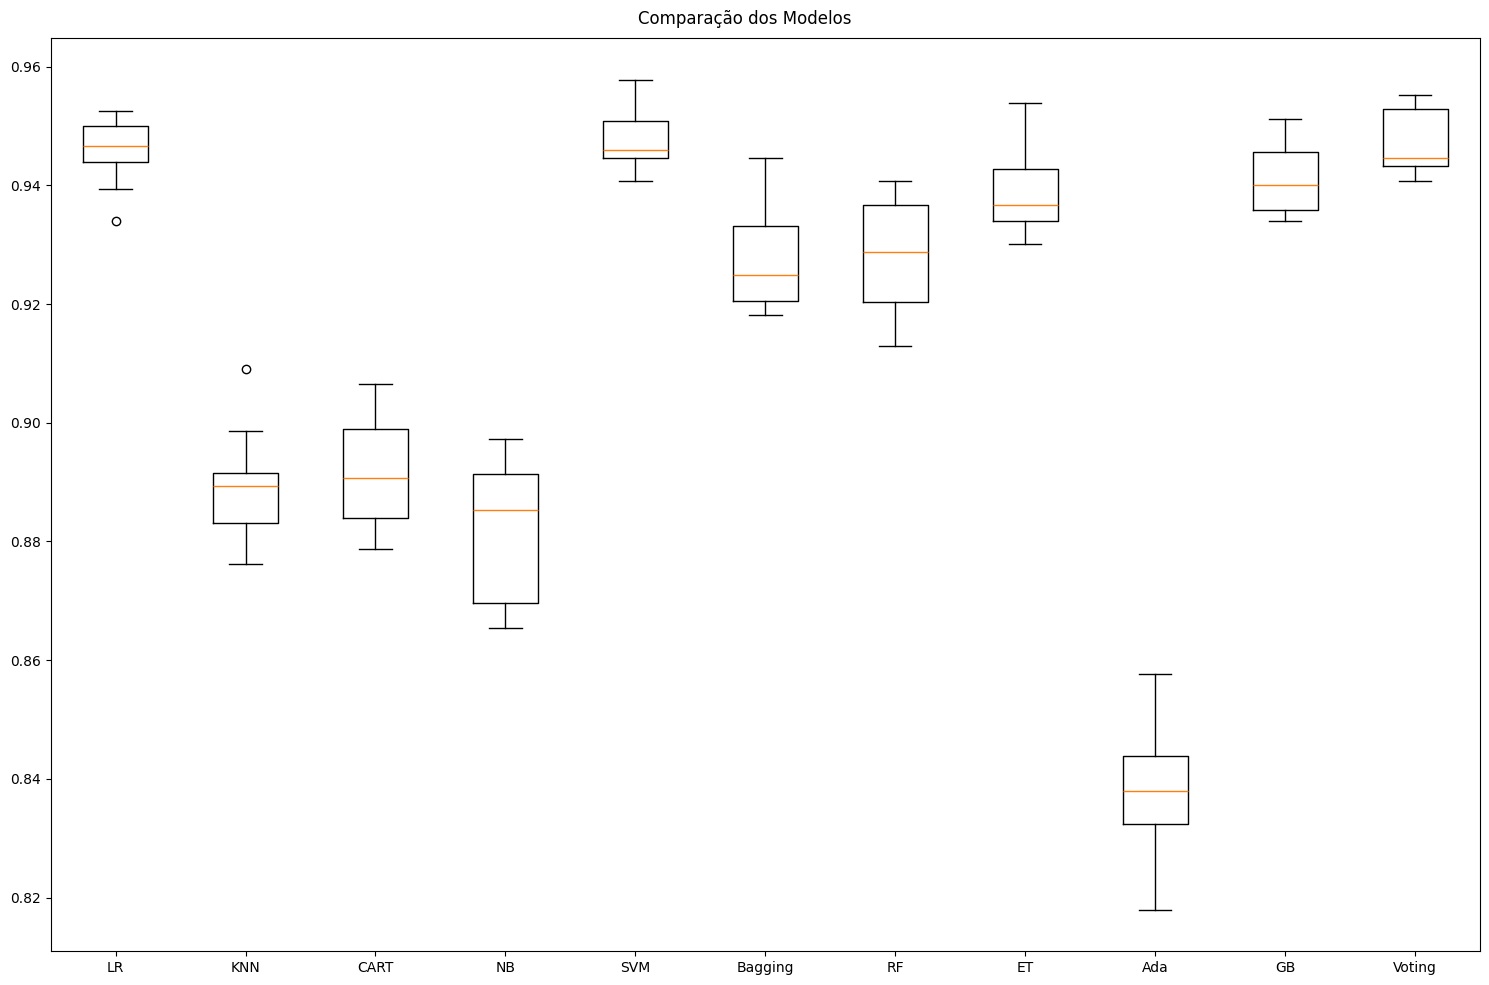

In [37]:
np.random.seed(7) # definindo uma semente global

# Lista que armazenará os modelos
models = []

# Criando os modelos e adicionando-os na lista de modelos
models.append(('LR', LogisticRegression(max_iter=200)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# Definindo os parâmetros do classificador base para o BaggingClassifier
base = DecisionTreeClassifier()
num_trees = 100
max_features = 3

# Criando os modelos para o VotingClassifier
bases = []
model1 = LogisticRegression(max_iter=200)
bases.append(('logistic', model1))
model2 = DecisionTreeClassifier()
bases.append(('cart', model2))
model3 = SVC()
bases.append(('svm', model3))

# Criando os ensembles e adicionando-os na lista de modelos
models.append(('Bagging', BaggingClassifier(estimator=base, n_estimators=num_trees)))
models.append(('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('Ada', AdaBoostClassifier(n_estimators=num_trees)))
models.append(('GB', GradientBoostingClassifier(n_estimators=num_trees)))
models.append(('Voting', VotingClassifier(bases)))

# Listas para armazenar os resultados
results = []
names = []

# Avaliação dos modelos (treinamento)
for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(15,10))
fig.suptitle('Comparação dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

## Criação e avaliação de modelos: dados padronizados e normalizados

LR-orig: 0.946 (0.005)
KNN-orig: 0.889 (0.009)
CART-orig: 0.892 (0.010)
NB-orig: 0.882 (0.012)
SVM-orig: 0.947 (0.005)
Bag-orig: 0.928 (0.009)
RF-orig: 0.928 (0.009)
ET-orig: 0.939 (0.008)
Ada-orig: 0.838 (0.011)
GB-orig: 0.941 (0.006)
Vot-orig: 0.947 (0.005)
LR-padr: 0.950 (0.004)
KNN-padr: 0.891 (0.010)
CART-padr: 0.892 (0.015)
NB-padr: 0.879 (0.011)
SVM-padr: 0.947 (0.009)
Bag-padr: 0.927 (0.011)
RF-padr: 0.928 (0.011)
ET-padr: 0.936 (0.011)
Ada-padr: 0.838 (0.011)
GB-padr: 0.941 (0.006)
Vot-padr: 0.950 (0.005)
LR-norm: 0.948 (0.004)
KNN-norm: 0.888 (0.012)
CART-norm: 0.891 (0.013)
NB-norm: 0.879 (0.011)
SVM-norm: 0.948 (0.011)
Bag-norm: 0.926 (0.010)
RF-norm: 0.931 (0.010)
ET-norm: 0.937 (0.009)
Ada-norm: 0.838 (0.011)
GB-norm: 0.941 (0.006)
Vot-norm: 0.948 (0.007)


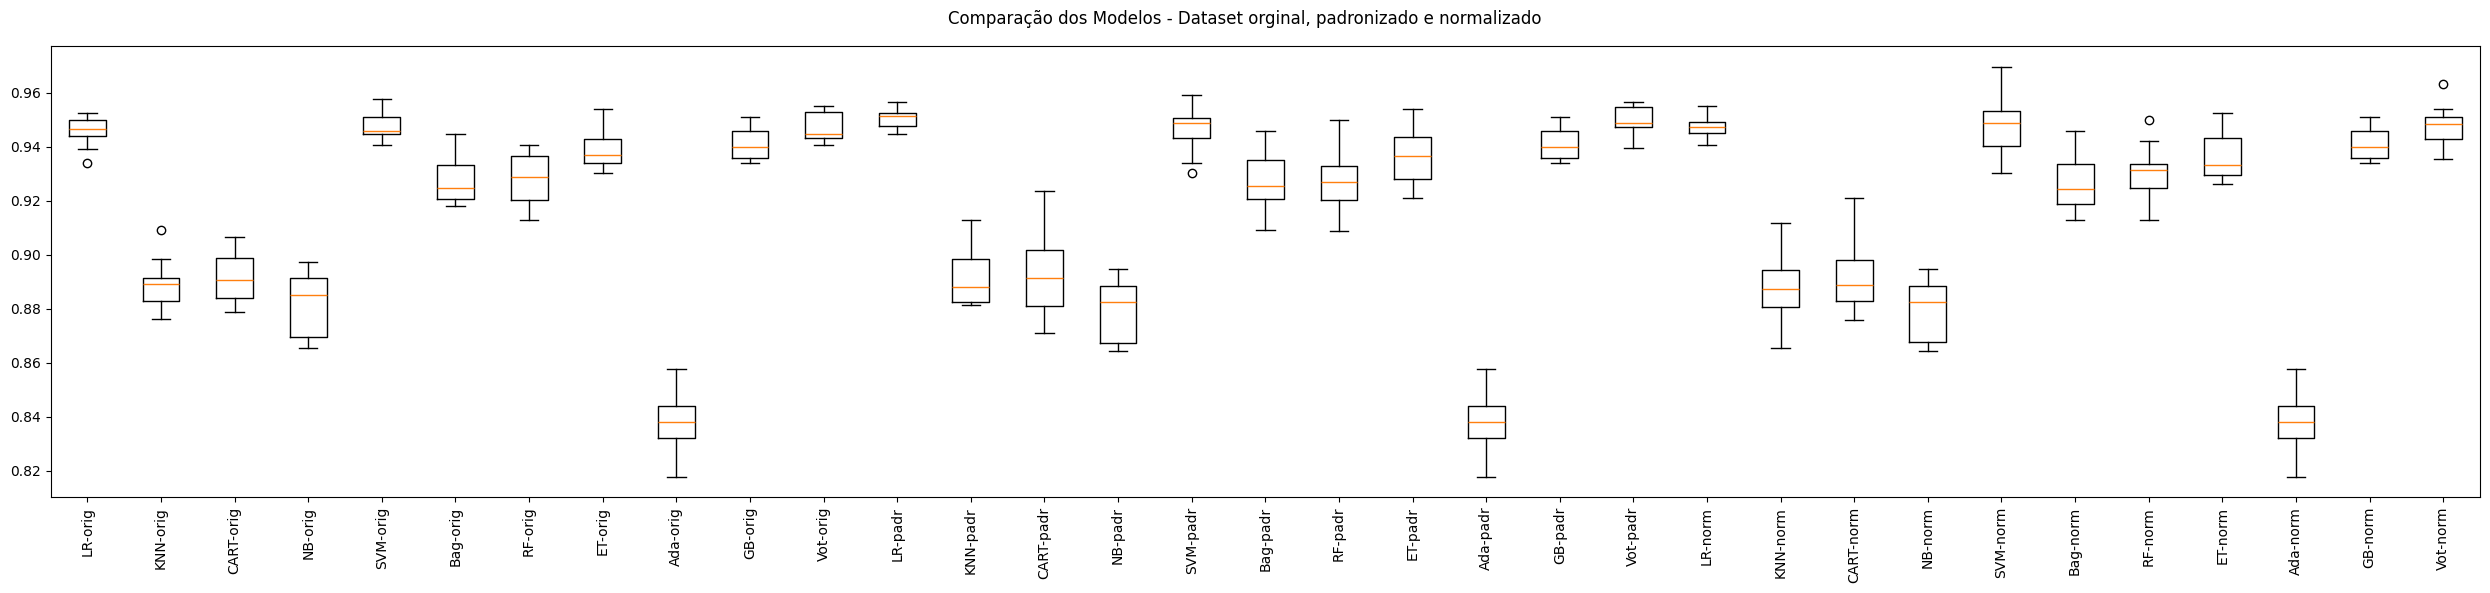

In [38]:
np.random.seed(7) # definindo uma semente global para este bloco

# Listas para armazenar os armazenar os pipelines e os resultados para todas as visões do dataset
pipelines = []
results = []
names = []


# Criando os elementos do pipeline

# Algoritmos que serão utilizados
reg_log = ('LR', LogisticRegression(max_iter=200))
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())
bagging = ('Bag', BaggingClassifier(estimator=base, n_estimators=num_trees))
random_forest = ('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features))
extra_trees = ('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features))
adaboost = ('Ada', AdaBoostClassifier(n_estimators=num_trees))
gradient_boosting = ('GB', GradientBoostingClassifier(n_estimators=num_trees))
voting = ('Voting', VotingClassifier(bases))

# Transformações que serão utilizadas
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())


# Montando os pipelines
# A ordem de execução é da esquerda para a direita.

# Dataset original
pipelines.append(('LR-orig', Pipeline([reg_log])))
pipelines.append(('KNN-orig', Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig', Pipeline([naive_bayes])))
pipelines.append(('SVM-orig', Pipeline([svm])))
pipelines.append(('Bag-orig', Pipeline([bagging])))
pipelines.append(('RF-orig', Pipeline([random_forest])))
pipelines.append(('ET-orig', Pipeline([extra_trees])))
pipelines.append(('Ada-orig', Pipeline([adaboost])))
pipelines.append(('GB-orig', Pipeline([gradient_boosting])))
pipelines.append(('Vot-orig', Pipeline([voting])))

# Dataset Padronizado
pipelines.append(('LR-padr', Pipeline([standard_scaler, reg_log])))
pipelines.append(('KNN-padr', Pipeline([standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
pipelines.append(('SVM-padr', Pipeline([standard_scaler, svm])))
pipelines.append(('Bag-padr', Pipeline([standard_scaler, bagging])))
pipelines.append(('RF-padr', Pipeline([standard_scaler, random_forest])))
pipelines.append(('ET-padr', Pipeline([standard_scaler, extra_trees])))
pipelines.append(('Ada-padr', Pipeline([standard_scaler, adaboost])))
pipelines.append(('GB-padr', Pipeline([standard_scaler, gradient_boosting])))
pipelines.append(('Vot-padr', Pipeline([standard_scaler, voting])))

# Dataset Normalizado
pipelines.append(('LR-norm', Pipeline([min_max_scaler, reg_log])))
pipelines.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([min_max_scaler, cart])))
pipelines.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
pipelines.append(('SVM-norm', Pipeline([min_max_scaler, svm])))
pipelines.append(('Bag-norm', Pipeline([min_max_scaler, bagging])))
pipelines.append(('RF-norm', Pipeline([min_max_scaler, random_forest])))
pipelines.append(('ET-norm', Pipeline([min_max_scaler, extra_trees])))
pipelines.append(('Ada-norm', Pipeline([min_max_scaler, adaboost])))
pipelines.append(('GB-norm', Pipeline([min_max_scaler, gradient_boosting])))
pipelines.append(('Vot-norm', Pipeline([min_max_scaler, voting])))

# Executando os pipelines
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()) # formatando para 3 casas decimais
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()

## Otimização dos hiperparâmetros

In [39]:
np.random.seed(7)  # Definindo uma semente global para este bloco

# Lista de modelos
models = []

# Criando os modelos e adicionando-os na lista de modelos
models.append(('LR', LogisticRegression(max_iter=200)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# Definindo os parâmetros do classificador base para o BaggingClassifier
base = DecisionTreeClassifier()
num_trees = 100
max_features = 3

# Criando os modelos para o VotingClassifier
bases = []
model1 = LogisticRegression(max_iter=200)
bases.append(('logistic', model1))
model2 = DecisionTreeClassifier()
bases.append(('cart', model2))
model3 = SVC()
bases.append(('svm', model3))

# Criando os ensembles e adicionando-os na lista de modelos
models.append(('Bagging', BaggingClassifier(estimator=base, n_estimators=num_trees)))
models.append(('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('Ada', AdaBoostClassifier(n_estimators=num_trees)))
models.append(('GB', GradientBoostingClassifier(n_estimators=num_trees)))
models.append(('Voting', VotingClassifier(estimators=bases, voting='hard')))

# Definindo os componentes do pipeline
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

# Lista de pipelines
pipelines = []

# Criando pipelines para cada modelo
for name, model in models:
    pipelines.append((name + '-orig', Pipeline(steps=[(name, model)])))
    pipelines.append((name + '-padr', Pipeline(steps=[standard_scaler, (name, model)])))
    pipelines.append((name + '-norm', Pipeline(steps=[min_max_scaler, (name, model)])))

# Definindo os parâmetros para GridSearchCV
param_grids = {
    'LR': {
        'LR__C': [0.01, 0.1, 1, 10, 100],
        'LR__solver': ['liblinear', 'saga']
    },
    'KNN': {
        'KNN__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
        'KNN__metric': ["euclidean", "manhattan", "minkowski"]
    },
    'CART': {
        'CART__max_depth': [None, 10, 20, 30, 40, 50],
        'CART__min_samples_split': [2, 5, 10],
        'CART__min_samples_leaf': [1, 2, 4]
    },
    'NB': {
        'NB__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    },
    'SVM': {
        'SVM__C': [0.1, 1, 10, 100],
        'SVM__gamma': [1, 0.1, 0.01, 0.001],
        'SVM__kernel': ['rbf', 'linear']
    },
    'RF': {
        'RF__n_estimators': [10, 50, 100, 200],
        'RF__max_features': ['auto', 'sqrt', 'log2'],
        'RF__max_depth': [None, 10, 20, 30],
        'RF__min_samples_split': [2, 5, 10],
        'RF__min_samples_leaf': [1, 2, 4]
    },
    'ET': {
        'ET__n_estimators': [10, 50, 100, 200],
        'ET__max_features': ['auto', 'sqrt', 'log2'],
        'ET__max_depth': [None, 10, 20, 30],
        'ET__min_samples_split': [2, 5, 10],
        'ET__min_samples_leaf': [1, 2, 4]
    },
    'Ada': {
        'Ada__n_estimators': [10, 50, 100, 200],
        'Ada__learning_rate': [0.01, 0.1, 1, 10]
    },
    'GB': {
        'GB__n_estimators': [10, 50, 100, 200],
        'GB__learning_rate': [0.01, 0.1, 0.2, 0.3],
        'GB__max_depth': [3, 5, 7, 9]
    },
    'Voting': {
        # Para VotingClassifier, geralmente não há hiperparâmetros para ajustar diretamente
        # Ajustar os hiperparâmetros dos estimadores base individualmente se necessário
    }
}

# Parâmetros de cross-validation e scoring
scoring = 'accuracy'
kfold = 5

# Executando o GridSearchCV para cada pipeline
for name, pipeline in pipelines:
    model_type = name.split('-')[0]
    if model_type in param_grids:
        param_grid = param_grids[model_type]
    else:
        param_grid = {}  # Para modelos que não têm parâmetros definidos

    grid = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring=scoring, cv=kfold)
    grid.fit(X_train, y_train)
    # Imprimindo a melhor configuração
    print("Modelo: %s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))

Modelo: LR-orig - Melhor: 0.937656 usando {'LR__C': 1, 'LR__solver': 'saga'}
Modelo: LR-padr - Melhor: 0.949123 usando {'LR__C': 100, 'LR__solver': 'saga'}
Modelo: LR-norm - Melhor: 0.949123 usando {'LR__C': 100, 'LR__solver': 'saga'}
Modelo: KNN-orig - Melhor: 0.913272 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 21}
Modelo: KNN-padr - Melhor: 0.915513 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 21}
Modelo: KNN-norm - Melhor: 0.915513 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 21}
Modelo: CART-orig - Melhor: 0.901279 usando {'CART__max_depth': 10, 'CART__min_samples_leaf': 4, 'CART__min_samples_split': 2}
Modelo: CART-padr - Melhor: 0.902465 usando {'CART__max_depth': 10, 'CART__min_samples_leaf': 4, 'CART__min_samples_split': 2}
Modelo: CART-norm - Melhor: 0.902729 usando {'CART__max_depth': 10, 'CART__min_samples_leaf': 4, 'CART__min_samples_split': 2}
Modelo: NB-orig - Melhor: 0.900355 usando {'NB__var_smoothing': 1e-05}
Modelo: NB-padr - Melhor:

## Finalização do Modelo

In [40]:
np.random.seed(7)

# Pipeline com normalização + modelo
model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('SVM', SVC(C=100, gamma=0.01, kernel='rbf'))
])

# Treinamento
model.fit(X_train, y_train)

# Predição
predictions = model.predict(X_test)

# Avaliação
print(accuracy_score(y_test, predictions))

0.9441222983658408


### O valor 0.951 vem da validação cruzada no treino (estimativa), enquanto 0.944 é o desempenho real no conjunto de teste. Essa pequena diferença é normal e indica que o modelo generaliza bem, sem overfitting significativo.

In [41]:
# Ajusta o scaler APENAS com o conjunto de treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Aplica o mesmo scaler no teste
X_test_scaled = scaler.transform(X_test)

# Treina o modelo com os dados escalados
model = SVC()
model.fit(X_train_scaled, y_train)

# avaliacao
predictions = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.940959409594096


Rodando o modelo a partir de um pipeline com os hiperparâmetros otimizados.

In [42]:
np.random.seed(7)

model = SVC(C=100, gamma=0.01, kernel='rbf')

pipeline = Pipeline(steps=[
    ('MinMaxScaler', MinMaxScaler()),
    ('SVM', model)
])

pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(accuracy_score(y_test, predictions))

0.9441222983658408


# Simulando a aplicação do modelo em dados não vistos

In [43]:
# Preparação do modelo com TODO o dataset
scaler = MinMaxScaler().fit(X) # ajuste do scaler com TODO o dataset
rescaledX = scaler.transform(X) # aplicação da normalização com TODO o dataset
model.fit(rescaledX, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.01
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [44]:
df_original.head()

,Age,Gender,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,Exercise_Frequency_per_Week,Daily_Sleep_Hours,Caffeine_Intake_Cups,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk
0,24,Male,Working,4.81,6.93,2.61,2.07,News,5.41,6.84,1.52,11.42,4.95,4.13,5.74,4.67,6.27,6.13,6.45,4.28,Medium
1,21,Male,Student,4.16,7.94,1.85,3.58,Gaming,3.41,7.88,2.23,6.98,5.91,3.63,5.75,5.38,7.37,6.27,3.74,5.23,Medium
2,25,Male,Student,3.07,7.45,2.96,2.85,Entertainment,3.40,6.39,0.53,7.79,4.06,5.67,6.03,2.41,6.48,4.82,6.69,3.72,High
3,22,Female,Student,4.41,7.34,4.51,3.37,Educational,2.19,7.92,0.58,6.61,6.10,4.78,4.85,5.86,7.27,5.17,5.96,3.97,High
4,24,Male,Student,2.97,5.76,2.36,1.77,Educational,4.93,5.97,1.64,4.81,5.22,4.23,5.05,5.54,6.34,5.72,2.22,4.63,Medium


In [45]:
entrada = pd.DataFrame([{
    "Age": 25,
    "Gender": 0,
    "Student_Working_Status": 0,
    "Daily_Social_Media_Hours": 4.81,
    "Screen_Time_Hours": 6.93,
    "Night_Scrolling_Frequency": 2.61,
    "Online_Gaming_Hours": 2.07,
    "Content_Type_Preference": 2,
    "Exercise_Frequency_per_Week": 5.41,
    "Daily_Sleep_Hours": 6.84,
    "Caffeine_Intake_Cups": 1.52,
    "Study_Work_Hours_per_Day": 11.42,
    "Overthinking_Score": 4.95,
    "Anxiety_Score": 4.13,
    "Mood_Stability_Score": 5.74,
    "Social_Comparison_Index": 4.67,
    "Sleep_Quality_Score": 6.27,
    "Motivation_Level": 6.13,
    "Emotional_Fatigue_Score": 6.45,
    "Wellbeing_Index": 4.28
}])

# Aplicar o mesmo scaler usado no treinamento final
entrada_scaled = scaler.transform(entrada)

# Previsão
saida = model.predict(entrada_scaled)

# Se estiver usando LabelBinarizer
saidas = le.inverse_transform(saida)

print(saidas)

['Medium']


In [46]:
entrada = pd.DataFrame([{
    "Age": 20,
    "Gender": 1,
    "Student_Working_Status": 0,
    "Daily_Social_Media_Hours": 0.5,
    "Screen_Time_Hours": 5,
    "Night_Scrolling_Frequency": 0.8,
    "Online_Gaming_Hours": 0,
    "Content_Type_Preference": 4,
    "Exercise_Frequency_per_Week": 2.1,
    "Daily_Sleep_Hours": 9,
    "Caffeine_Intake_Cups": 0,
    "Study_Work_Hours_per_Day": 0,
    "Overthinking_Score": 4,
    "Anxiety_Score": 6,
    "Mood_Stability_Score": 6,
    "Social_Comparison_Index": 2,
    "Sleep_Quality_Score": 6,
    "Motivation_Level": 5,
    "Emotional_Fatigue_Score": 7,
    "Wellbeing_Index": 4
}])

# Aplicar o mesmo scaler usado no treinamento final
entrada_scaled = scaler.transform(entrada)

# Previsão
saida = model.predict(entrada_scaled)

# Se estiver usando LabelBinarizer
saidas = le.inverse_transform(saida)

print(saidas)

['High']


In [47]:
entrada = pd.DataFrame([{
    "Age": 20,
    "Gender": 1,
    "Student_Working_Status": 0,
    "Daily_Social_Media_Hours": 0.40,
    "Screen_Time_Hours": 5.0	,
    "Night_Scrolling_Frequency": 0.23,
    "Online_Gaming_Hours": 0.50,
    "Content_Type_Preference": 3,
    "Exercise_Frequency_per_Week": 5.19,
    "Daily_Sleep_Hours": 10,
    "Caffeine_Intake_Cups": 3,
    "Study_Work_Hours_per_Day": 6,
    "Overthinking_Score": 2,
    "Anxiety_Score": 1.2,
    "Mood_Stability_Score": 7,
    "Social_Comparison_Index": 1.79,
    "Sleep_Quality_Score": 9.5,
    "Motivation_Level": 6.80,
    "Emotional_Fatigue_Score": 3.28,
    "Wellbeing_Index": 8.07
}])

# Aplicar o mesmo scaler usado no treinamento final
entrada_scaled = scaler.transform(entrada)

# Previsão
saida = model.predict(entrada_scaled)

# Se estiver usando LabelBinarizer
saidas = le.inverse_transform(saida)

print(saidas)

['Low']


# Salvando os Dados

In [48]:
dirs = {
    "models": "../models",
    "scalers": "../scalers",
    "pipelines": "../pipelines",
    "data": "../data"
}

# Criar diretórios se não existirem
for path in dirs.values():
    os.makedirs(path, exist_ok=True)

# Salvando o modelo
model_filename = os.path.join(dirs["models"], "svm_gen_z_classifier.pkl")
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

# Salvando o scaler (se estiver separado; se usar pipeline, isso é opcional)
scaler_filename = os.path.join(dirs["scalers"], "minmax_scaler_gen_z.pkl")
with open(scaler_filename, 'wb') as file:
    pickle.dump(pipeline.named_steps['MinMaxScaler'], file)

# Salvando o pipeline (recomendado)
pipeline_filename = os.path.join(dirs["pipelines"], "svm_gen_z_pipeline.pkl")
with open(pipeline_filename, 'wb') as file:
    pickle.dump(pipeline, file)

# Salvando X_test e y_test
X_test_df = pd.DataFrame(X_test, columns=df_copy.columns[:-1])
y_test_df = pd.DataFrame(y_test, columns=[df_copy.columns[-1]])

X_test_df.to_csv(os.path.join(dirs["data"], "X_test_dataset_gen_z.csv"), index=False)
y_test_df.to_csv(os.path.join(dirs["data"], "y_test_dataset_gen_z.csv"), index=False)